# Proyecto 4 - Predicción del consumo energético de un edificio

## Corte 1 - Baseline y primer modelo de regresión

**Asignatura:** Profundización III - Inteligencia Artificial  
**Dataset:** UCI Appliances Energy Prediction  
**Tarea:** Regresión temporal  
**Variable objetivo:** `Appliances` (Wh)

### Objetivo

Construir y evaluar líneas base para la predicción del consumo energético utilizando exclusivamente información disponible en el conjunto de entrenamiento.

Los resultados se evaluarán sobre un bloque temporal de validación mediante:

- MAE
- RMSE
- R²

Posteriormente, estos resultados servirán como referencia para determinar si un primer modelo de aprendizaje automático aporta una mejora real.

El conjunto de prueba final permanecerá reservado.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("/content/energydata_complete.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

# Características temporales
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["weekend"] = (df["day_of_week"] >= 5).astype(int)

print(df.shape)
df.head()

(19735, 33)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day_of_week,month,weekend
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17,0,1,0
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17,0,1,0
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17,0,1,0
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17,0,1,0
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17,0,1,0


In [ ]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("Train:", len(train))
print("Validation:", len(validation))
print("Test reservado:", len(test))

print("\nFin Train:", train["date"].max())
print("Inicio Validation:", validation["date"].min())
print("Inicio Test:", test["date"].min())

Train: 13814
Validation: 2960
Test reservado: 2961

Fin Train: 2016-04-16 15:10:00
Inicio Validation: 2016-04-16 15:20:00
Inicio Test: 2016-05-07 04:40:00


In [ ]:
y_train = train["Appliances"]
y_val = validation["Appliances"]

print("Train target:", y_train.shape)
print("Validation target:", y_val.shape)

Train target: (13814,)
Validation target: (2960,)


In [ ]:
y_train = train["Appliances"]
y_val = validation["Appliances"]

print("Train target:", y_train.shape)
print("Validation target:", y_val.shape)

Train target: (13814,)
Validation target: (2960,)


In [ ]:
train_median = y_train.median()
pred_baseline_median = np.full(
    len(validation),
    train_median
)

pred_baseline_median[:10]

array([60., 60., 60., 60., 60., 60., 60., 60., 60., 60.])

In [ ]:
mae_median = mean_absolute_error(
    y_val,
    pred_baseline_median
)

print(f"MAE baseline mediana: {mae_median:.2f} Wh")

MAE baseline mediana: 42.60 Wh


In [ ]:
rmse_median = np.sqrt(
    mean_squared_error(
        y_val,
        pred_baseline_median
    )
)

print(f"RMSE baseline mediana: {rmse_median:.2f} Wh")

RMSE baseline mediana: 98.11 Wh


In [ ]:
r2_median = r2_score(
    y_val,
    pred_baseline_median
)

print(f"R² baseline mediana: {r2_median:.4f}")

R² baseline mediana: -0.1313


In [ ]:
resultados = pd.DataFrame({
    "Modelo": ["Baseline - Mediana histórica"],
    "MAE": [mae_median],
    "RMSE": [rmse_median],
    "R2": [r2_median]
})

resultados

,Modelo,MAE,RMSE,R2
0,Baseline - Mediana histórica,42.60473,98.107601,-0.131293


### Resultados del baseline de mediana histórica

El baseline basado en la mediana histórica obtuvo sobre el conjunto de validación un MAE de 42,60 Wh, un RMSE de 98,11 Wh y un R² de -0,1313.

La diferencia considerable entre MAE y RMSE indica que existen errores de gran magnitud que son penalizados con mayor intensidad por RMSE. Este comportamiento es consistente con el análisis exploratorio, donde se identificaron episodios puntuales de consumo elevado.

El R² negativo evidencia que utilizar una predicción constante basada en la mediana no explica adecuadamente la variabilidad temporal del consumo. Este resultado no invalida la línea base; establece una referencia cuantitativa sencilla que los modelos posteriores deberán intentar superar.

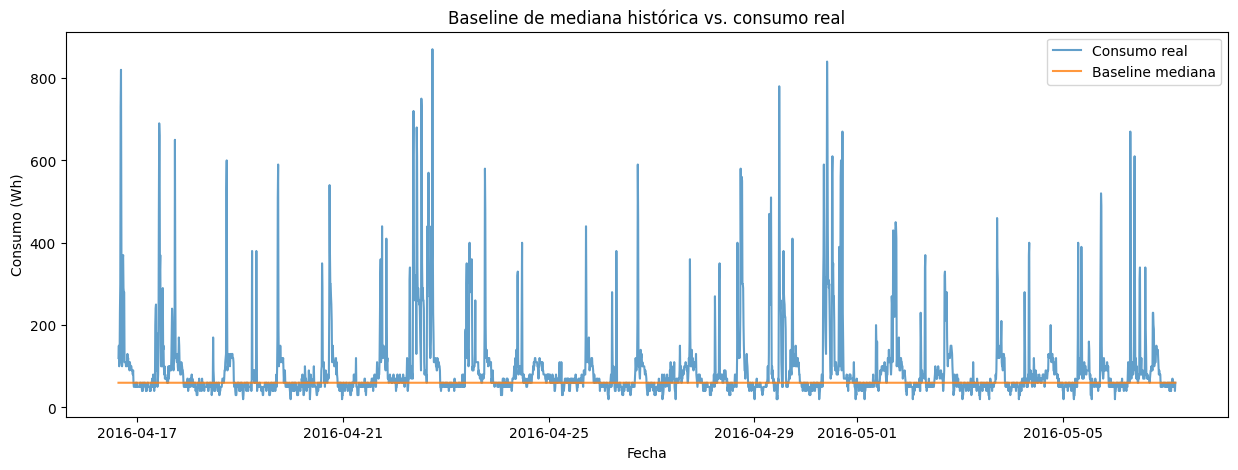

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    validation["date"],
    y_val,
    label="Consumo real",
    alpha=0.7
)

plt.plot(
    validation["date"],
    pred_baseline_median,
    label="Baseline mediana",
    alpha=0.8
)

plt.xlabel("Fecha")
plt.ylabel("Consumo (Wh)")
plt.title("Baseline de mediana histórica vs. consumo real")
plt.legend()

plt.show()

### Baseline 1: mediana histórica

Como primera línea base se utilizó la mediana de `Appliances` calculada exclusivamente sobre el conjunto de entrenamiento.

El baseline asigna este mismo valor a todas las observaciones del conjunto de validación, sin utilizar información procedente de Validation o Test.

Esta estrategia representa una referencia deliberadamente sencilla contra la cual se evaluará si modelos que incorporen información temporal y ambiental producen una mejora cuantitativa.

In [ ]:
median_by_hour = (
    train.groupby("hour")["Appliances"]
    .median()
)

median_by_hour

,Appliances
hour,
0,50.0
1,50.0
2,50.0
3,50.0
4,50.0
5,50.0
6,50.0
7,50.0
8,60.0


In [ ]:
print("Hora con menor mediana:",
      median_by_hour.idxmin(),
      "-",
      median_by_hour.min(),
      "Wh")

print("Hora con mayor mediana:",
      median_by_hour.idxmax(),
      "-",
      median_by_hour.max(),
      "Wh")

Hora con menor mediana: 0 - 50.0 Wh
Hora con mayor mediana: 18 - 120.0 Wh


In [ ]:
pred_baseline_hour = (
    validation["hour"]
    .map(median_by_hour)
    .to_numpy()
)

pred_baseline_hour[:20]

array([ 80.,  80.,  80.,  80.,  80.,  80.,  80.,  80.,  80.,  80.,  90.,
        90.,  90.,  90.,  90.,  90., 120., 120., 120., 120.])

In [ ]:
print(
    "Predicciones faltantes:",
    np.isnan(pred_baseline_hour).sum()
)

Predicciones faltantes: 0


In [ ]:
mae_hour = mean_absolute_error(
    y_val,
    pred_baseline_hour
)

rmse_hour = np.sqrt(
    mean_squared_error(
        y_val,
        pred_baseline_hour
    )
)

r2_hour = r2_score(
    y_val,
    pred_baseline_hour
)

print(f"MAE baseline horario: {mae_hour:.2f} Wh")
print(f"RMSE baseline horario: {rmse_hour:.2f} Wh")
print(f"R² baseline horario: {r2_hour:.4f}")

MAE baseline horario: 36.83 Wh
RMSE baseline horario: 91.33 Wh
R² baseline horario: 0.0195


In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "Baseline - Mediana histórica",
        "Baseline - Mediana por hora"
    ],
    "MAE": [
        mae_median,
        mae_hour
    ],
    "RMSE": [
        rmse_median,
        rmse_hour
    ],
    "R2": [
        r2_median,
        r2_hour
    ]
})

resultados

,Modelo,MAE,RMSE,R2
0,Baseline - Mediana histórica,42.604730,98.107601,-0.131293
1,Baseline - Mediana por hora,36.834459,91.333403,0.019542


### Comparación de las líneas base

El baseline temporal basado en la mediana del consumo por hora obtuvo un MAE de 36,83 Wh, un RMSE de 91,33 Wh y un R² de 0,0195 sobre el conjunto de validación.

Frente al baseline de mediana histórica, el uso de información horaria redujo el MAE en 13,54% y el RMSE en 6,90%. Esto confirma que la estructura temporal identificada durante el análisis exploratorio contiene información predictiva útil.

La mediana horaria más baja se observó a las 00:00 con 50 Wh, mientras que la mayor se presentó a las 18:00 con 120 Wh, consistente con el incremento de consumo observado durante las últimas horas de la tarde.

Sin embargo, el R² permanece cercano a cero y el RMSE continúa siendo considerablemente superior al MAE. Por lo tanto, conocer únicamente la hora del día no permite representar adecuadamente toda la variabilidad del consumo, especialmente los episodios de mayor magnitud.

El baseline horario se adopta como la línea base temporal principal contra la cual se comparará el primer modelo de aprendizaje automático.

In [ ]:
mejora_mae = (
    (mae_median - mae_hour)
    / mae_median
    * 100
)

mejora_rmse = (
    (rmse_median - rmse_hour)
    / rmse_median
    * 100
)

print(
    f"Reducción de MAE respecto al baseline inicial: "
    f"{mejora_mae:.2f}%"
)

print(
    f"Reducción de RMSE respecto al baseline inicial: "
    f"{mejora_rmse:.2f}%"
)

Reducción de MAE respecto al baseline inicial: 13.54%
Reducción de RMSE respecto al baseline inicial: 6.90%


## Primer modelo: Regresión Lineal

Como primer modelo de aprendizaje automático se utilizará una regresión lineal.

Se excluye `date` como entrada directa y se utilizan las características temporales derivadas previamente. También se excluyen `rv1` y `rv2` en esta primera versión debido a su naturaleza aleatoria y a la redundancia exacta identificada durante el EDA.

Cualquier variable construida a partir de `Appliances`, como el indicador exploratorio de consumo alto, debe excluirse de las entradas porque introduciría fuga de información de la variable objetivo.

In [ ]:
excluded_cols = [
    "date",
    "Appliances",
    "rv1",
    "rv2"
]

feature_cols = [
    col for col in train.columns
    if col not in excluded_cols
]

print("Número de características:", len(feature_cols))
print(feature_cols)

Número de características: 29
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'day_of_week', 'month', 'weekend']


In [ ]:
X_train = train[feature_cols].copy()
X_val = validation[feature_cols].copy()

y_train = train["Appliances"].copy()
y_val = validation["Appliances"].copy()

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (13814, 29)
X_val: (2960, 29)
y_train: (13814,)
y_val: (2960,)


In [ ]:
print(
    "Nulos en X_train:",
    X_train.isnull().sum().sum()
)

print(
    "Nulos en X_val:",
    X_val.isnull().sum().sum()
)

Nulos en X_train: 0
Nulos en X_val: 0


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [ ]:
pred_linear = linear_model.predict(X_val)

print("Número de predicciones:", len(pred_linear))
print("Primeras 5 predicciones:", pred_linear[:5])

Número de predicciones: 2960
Primeras 5 predicciones: [194.15767954 184.23807249 178.87847198 181.45955614 185.95856551]


In [ ]:
mae_linear = mean_absolute_error(
    y_val,
    pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_val,
        pred_linear
    )
)

r2_linear = r2_score(
    y_val,
    pred_linear
)

print(f"MAE Regresión Lineal: {mae_linear:.2f} Wh")
print(f"RMSE Regresión Lineal: {rmse_linear:.2f} Wh")
print(f"R² Regresión Lineal: {r2_linear:.4f}")

MAE Regresión Lineal: 52.72 Wh
RMSE Regresión Lineal: 86.20 Wh
R² Regresión Lineal: 0.1266


In [ ]:
mejora_linear_mae = (
    (mae_hour - mae_linear)
    / mae_hour
    * 100
)

mejora_linear_rmse = (
    (rmse_hour - rmse_linear)
    / rmse_hour
    * 100
)

print(
    f"Cambio MAE vs baseline horario: "
    f"{mejora_linear_mae:.2f}%"
)

print(
    f"Cambio RMSE vs baseline horario: "
    f"{mejora_linear_rmse:.2f}%"
)

Cambio MAE vs baseline horario: -43.13%
Cambio RMSE vs baseline horario: 5.62%


In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "Baseline - Mediana histórica",
        "Baseline - Mediana por hora",
        "Regresión Lineal"
    ],
    "MAE": [
        mae_median,
        mae_hour,
        mae_linear
    ],
    "RMSE": [
        rmse_median,
        rmse_hour,
        rmse_linear
    ],
    "R2": [
        r2_median,
        r2_hour,
        r2_linear
    ]
})

resultados

,Modelo,MAE,RMSE,R2
0,Baseline - Mediana histórica,42.604730,98.107601,-0.131293
1,Baseline - Mediana por hora,36.834459,91.333403,0.019542
2,Regresión Lineal,52.721664,86.203000,0.126597


### Resultados de la Regresión Lineal

La Regresión Lineal obtuvo un MAE de 52,72 Wh, un RMSE de 86,20 Wh y un R² de 0,1266 sobre el conjunto temporal de validación.

El resultado presenta un comportamiento diferente según la métrica utilizada. Frente al baseline temporal por hora, el MAE aumentó de 36,83 Wh a 52,72 Wh, lo que representa un empeoramiento del 43,13%. Sin embargo, el RMSE disminuyó de 91,33 Wh a 86,20 Wh, equivalente a una mejora del 5,62%.

El R² también aumentó de 0,0195 en el baseline horario a 0,1266 en la Regresión Lineal.

Por lo tanto, no puede afirmarse que la Regresión Lineal sea superior al baseline en todos los criterios. Los resultados sugieren un compromiso entre el error habitual medido mediante MAE y la penalización de errores de mayor magnitud representada por RMSE.

Será necesario analizar posteriormente los residuos y, en particular, los periodos de alto consumo para determinar qué tipo de observaciones explican esta diferencia entre métricas.

## Modelo Ridge

Como segunda alternativa lineal se utiliza regresión Ridge, que incorpora regularización L2.

Debido a que las variables predictoras se encuentran expresadas en diferentes escalas y unidades, se utiliza `StandardScaler` antes de aplicar Ridge. El escalador se ajusta exclusivamente con los datos de entrenamiento mediante un pipeline, evitando utilizar información del conjunto de validación durante el ajuste.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

print("Modelo Ridge entrenado correctamente.")

Modelo Ridge entrenado correctamente.


In [ ]:
pred_ridge = ridge_model.predict(X_val)

print("Número de predicciones:", len(pred_ridge))

Número de predicciones: 2960


In [ ]:
mae_ridge = mean_absolute_error(
    y_val,
    pred_ridge
)

rmse_ridge = np.sqrt(
    mean_squared_error(
        y_val,
        pred_ridge
    )
)

r2_ridge = r2_score(
    y_val,
    pred_ridge
)

print(f"MAE Ridge: {mae_ridge:.2f} Wh")
print(f"RMSE Ridge: {rmse_ridge:.2f} Wh")
print(f"R² Ridge: {r2_ridge:.4f}")

MAE Ridge: 52.76 Wh
RMSE Ridge: 86.21 Wh
R² Ridge: 0.1265


In [ ]:
cambio_ridge_mae = (
    (mae_linear - mae_ridge)
    / mae_linear
    * 100
)

cambio_ridge_rmse = (
    (rmse_linear - rmse_ridge)
    / rmse_linear
    * 100
)

print(
    f"Cambio MAE Ridge vs Lineal: "
    f"{cambio_ridge_mae:.2f}%"
)

print(
    f"Cambio RMSE Ridge vs Lineal: "
    f"{cambio_ridge_rmse:.2f}%"
)

Cambio MAE Ridge vs Lineal: -0.08%
Cambio RMSE Ridge vs Lineal: -0.00%


In [ ]:
resultados = pd.DataFrame({
    "Modelo": [
        "Baseline - Mediana histórica",
        "Baseline - Mediana por hora",
        "Regresión Lineal",
        "Ridge"
    ],
    "MAE": [
        mae_median,
        mae_hour,
        mae_linear,
        mae_ridge
    ],
    "RMSE": [
        rmse_median,
        rmse_hour,
        rmse_linear,
        rmse_ridge
    ],
    "R2": [
        r2_median,
        r2_hour,
        r2_linear,
        r2_ridge
    ]
})

resultados.round(4)

,Modelo,MAE,RMSE,R2
0,Baseline - Mediana histórica,42.6047,98.1076,-0.1313
1,Baseline - Mediana por hora,36.8345,91.3334,0.0195
2,Regresión Lineal,52.7217,86.2030,0.1266
3,Ridge,52.7614,86.2064,0.1265


### Comparación entre Regresión Lineal y Ridge

Ridge obtuvo un MAE de 52,76 Wh, un RMSE de 86,21 Wh y un R² de 0,1265. Estos resultados son prácticamente idénticos a los obtenidos mediante Regresión Lineal.

Respecto a la Regresión Lineal, Ridge presentó un cambio de -0,08% en MAE y aproximadamente 0% en RMSE. Por lo tanto, con la configuración inicial utilizada (`alpha=1.0`) la regularización L2 no produjo una mejora relevante sobre el conjunto temporal de validación.

También se verificó la plausibilidad física de las predicciones. Ninguno de los dos modelos produjo valores negativos en validación. La predicción mínima fue aproximadamente 13,23 Wh para Regresión Lineal y 13,26 Wh para Ridge.

Por el momento, no existe evidencia que justifique preferir Ridge sobre la Regresión Lineal. El análisis posterior de residuos permitirá estudiar con mayor detalle las diferencias entre los modelos y las líneas base.

In [ ]:
print(
    "Predicciones negativas - Lineal:",
    (pred_linear < 0).sum()
)

print(
    "Predicciones negativas - Ridge:",
    (pred_ridge < 0).sum()
)

print(
    "Predicción mínima Lineal:",
    pred_linear.min()
)

print(
    "Predicción mínima Ridge:",
    pred_ridge.min()
)

Predicciones negativas - Lineal: 0
Predicciones negativas - Ridge: 0
Predicción mínima Lineal: 13.234978266946996
Predicción mínima Ridge: 13.255386120665236


## Análisis de errores y periodos de alto consumo

Las métricas globales mostraron un comportamiento diferente entre el baseline horario y la Regresión Lineal. El baseline horario obtuvo menor MAE, mientras que la Regresión Lineal obtuvo menor RMSE y mayor R².

Para comprender esta diferencia se analizarán los residuos y el desempeño de ambos métodos durante periodos de consumo habitual y de alto consumo.

In [ ]:
errores = validation[
    ["date", "Appliances", "hour"]
].copy()

errores["pred_hour"] = pred_baseline_hour
errores["pred_linear"] = pred_linear

errores["resid_hour"] = (
    errores["Appliances"] - errores["pred_hour"]
)

errores["resid_linear"] = (
    errores["Appliances"] - errores["pred_linear"]
)

errores["abs_error_hour"] = abs(
    errores["resid_hour"]
)

errores["abs_error_linear"] = abs(
    errores["resid_linear"]
)

errores.head()

,date,Appliances,hour,pred_hour,pred_linear,resid_hour,resid_linear,abs_error_hour,abs_error_linear
13814,2016-04-16 15:20:00,120,15,80.0,194.157680,40.0,-74.157680,40.0,74.157680
13815,2016-04-16 15:30:00,150,15,80.0,184.238072,70.0,-34.238072,70.0,34.238072
13816,2016-04-16 15:40:00,100,15,80.0,178.878472,20.0,-78.878472,20.0,78.878472
13817,2016-04-16 15:50:00,110,15,80.0,181.459556,30.0,-71.459556,30.0,71.459556
13818,2016-04-16 16:00:00,230,16,80.0,185.958566,150.0,44.041434,150.0,44.041434


In [ ]:
p90_train = train["Appliances"].quantile(0.90)

print(
    f"Percentil 90 calculado solo con Train: "
    f"{p90_train:.2f} Wh"
)

Percentil 90 calculado solo con Train: 220.00 Wh


In [ ]:
errores["high_consumption"] = (
    errores["Appliances"] >= p90_train
)

print(
    errores["high_consumption"]
    .value_counts()
)

print()

print(
    errores["high_consumption"]
    .value_counts(normalize=True)
    * 100
)

high_consumption
False    2737
True      223
Name: count, dtype: int64

high_consumption
False    92.466216
True      7.533784
Name: proportion, dtype: float64


In [ ]:
normal = errores[
    ~errores["high_consumption"]
]

alto = errores[
    errores["high_consumption"]
]

print("=== CONSUMO NORMAL ===")

print(
    f"Baseline horario - MAE: "
    f"{normal['abs_error_hour'].mean():.2f} Wh"
)

print(
    f"Regresión Lineal - MAE: "
    f"{normal['abs_error_linear'].mean():.2f} Wh"
)

print("\n=== CONSUMO ALTO ===")

print(
    f"Baseline horario - MAE: "
    f"{alto['abs_error_hour'].mean():.2f} Wh"
)

print(
    f"Regresión Lineal - MAE: "
    f"{alto['abs_error_linear'].mean():.2f} Wh"
)

=== CONSUMO NORMAL ===
Baseline horario - MAE: 16.17 Wh
Regresión Lineal - MAE: 39.69 Wh

=== CONSUMO ALTO ===
Baseline horario - MAE: 290.40 Wh
Regresión Lineal - MAE: 212.64 Wh


In [ ]:
rmse_hour_normal = np.sqrt(
    np.mean(normal["resid_hour"] ** 2)
)

rmse_linear_normal = np.sqrt(
    np.mean(normal["resid_linear"] ** 2)
)

rmse_hour_high = np.sqrt(
    np.mean(alto["resid_hour"] ** 2)
)

rmse_linear_high = np.sqrt(
    np.mean(alto["resid_linear"] ** 2)
)

print("=== RMSE CONSUMO NORMAL ===")
print(
    f"Baseline horario: {rmse_hour_normal:.2f} Wh"
)
print(
    f"Regresión Lineal: {rmse_linear_normal:.2f} Wh"
)

print("\n=== RMSE CONSUMO ALTO ===")
print(
    f"Baseline horario: {rmse_hour_high:.2f} Wh"
)
print(
    f"Regresión Lineal: {rmse_linear_high:.2f} Wh"
)

=== RMSE CONSUMO NORMAL ===
Baseline horario: 23.89 Wh
Regresión Lineal: 50.57 Wh

=== RMSE CONSUMO ALTO ===
Baseline horario: 322.06 Wh
Regresión Lineal: 259.33 Wh


In [ ]:
print("=== RESIDUO MEDIO EN CONSUMO ALTO ===")

print(
    f"Baseline horario: "
    f"{alto['resid_hour'].mean():.2f} Wh"
)

print(
    f"Regresión Lineal: "
    f"{alto['resid_linear'].mean():.2f} Wh"
)

=== RESIDUO MEDIO EN CONSUMO ALTO ===
Baseline horario: 290.40 Wh
Regresión Lineal: 209.68 Wh


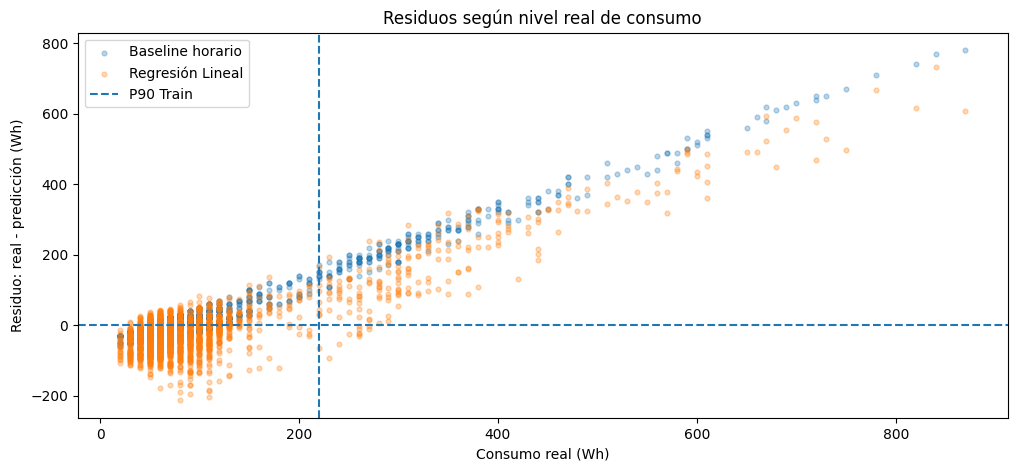

In [ ]:
plt.figure(figsize=(12, 5))

plt.scatter(
    errores["Appliances"],
    errores["resid_hour"],
    alpha=0.3,
    s=12,
    label="Baseline horario"
)

plt.scatter(
    errores["Appliances"],
    errores["resid_linear"],
    alpha=0.3,
    s=12,
    label="Regresión Lineal"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    p90_train,
    linestyle="--",
    label="P90 Train"
)

plt.xlabel("Consumo real (Wh)")
plt.ylabel("Residuo: real - predicción (Wh)")
plt.title(
    "Residuos según nivel real de consumo"
)

plt.legend()
plt.show()

In [ ]:
peores_lineal = (
    errores
    .nlargest(
        10,
        "abs_error_linear"
    )
    [
        [
            "date",
            "Appliances",
            "pred_linear",
            "resid_linear",
            "abs_error_linear",
            "hour"
        ]
    ]
)

peores_lineal

,date,Appliances,pred_linear,resid_linear,abs_error_linear,hour
15798,2016-04-30 10:00:00,840,107.983217,732.016783,732.016783,10
15664,2016-04-29 11:40:00,780,111.367971,668.632029,668.632029,11
13821,2016-04-16 16:30:00,820,203.916382,616.083618,616.083618,16
14693,2016-04-22 17:50:00,870,263.068622,606.931378,606.931378,17
16647,2016-05-06 07:30:00,670,77.277180,592.722820,592.722820,7
15799,2016-04-30 10:10:00,700,111.731815,588.268185,588.268185,10
14640,2016-04-22 09:00:00,720,144.066005,575.933995,575.933995,9
13928,2016-04-17 10:20:00,690,136.718406,553.281594,553.281594,10
13820,2016-04-16 16:20:00,730,200.715856,529.284144,529.284144,16
15841,2016-04-30 17:10:00,670,146.058723,523.941277,523.941277,17


### Interpretación del análisis de errores

Para evitar utilizar información de validación o prueba en la definición del criterio de consumo alto, el percentil 90 fue recalculado exclusivamente sobre el conjunto de entrenamiento. El umbral resultante fue de **220 Wh**, que se adopta para el análisis predictivo posterior.

Los resultados muestran comportamientos claramente diferentes entre el baseline horario y la Regresión Lineal.

Durante los periodos de consumo inferior a 220 Wh, el baseline horario obtuvo un MAE de **16,17 Wh**, considerablemente inferior a los **39,69 Wh** de la Regresión Lineal. Sin embargo, durante periodos de consumo alto, el comportamiento se invierte: el baseline horario alcanzó un MAE de **290,40 Wh**, mientras que la Regresión Lineal redujo el error a **212,64 Wh**.

El mismo patrón aparece mediante RMSE. Para consumo normal, el baseline horario obtuvo 23,89 Wh frente a 50,57 Wh de la Regresión Lineal. Para consumo alto, los errores aumentaron considerablemente hasta 322,06 Wh y 259,33 Wh respectivamente.

Estos resultados explican la diferencia observada previamente entre las métricas globales. El baseline horario obtiene mejor MAE porque representa adecuadamente gran parte de los consumos habituales. La Regresión Lineal, aunque comete mayores errores durante condiciones normales, reduce parcialmente algunos errores de gran magnitud y por ello obtiene mejor RMSE.

Además, el residuo medio durante periodos de alto consumo fue positivo para ambos métodos: +290,40 Wh para el baseline horario y +209,68 Wh para la Regresión Lineal. Debido a que el residuo fue definido como `real - predicción`, estos valores evidencian una tendencia sistemática a **subestimar los episodios de consumo elevado**.

El peor error absoluto de la Regresión Lineal ocurrió el 30 de abril de 2016 a las 10:00. El consumo real fue de 840 Wh, mientras que el modelo predijo aproximadamente 107,98 Wh, produciendo un error absoluto de 732,02 Wh.

Por lo tanto, aunque la Regresión Lineal mejora el RMSE global frente a las líneas base, los resultados muestran que la predicción de picos continúa siendo una de las principales limitaciones del modelo inicial.

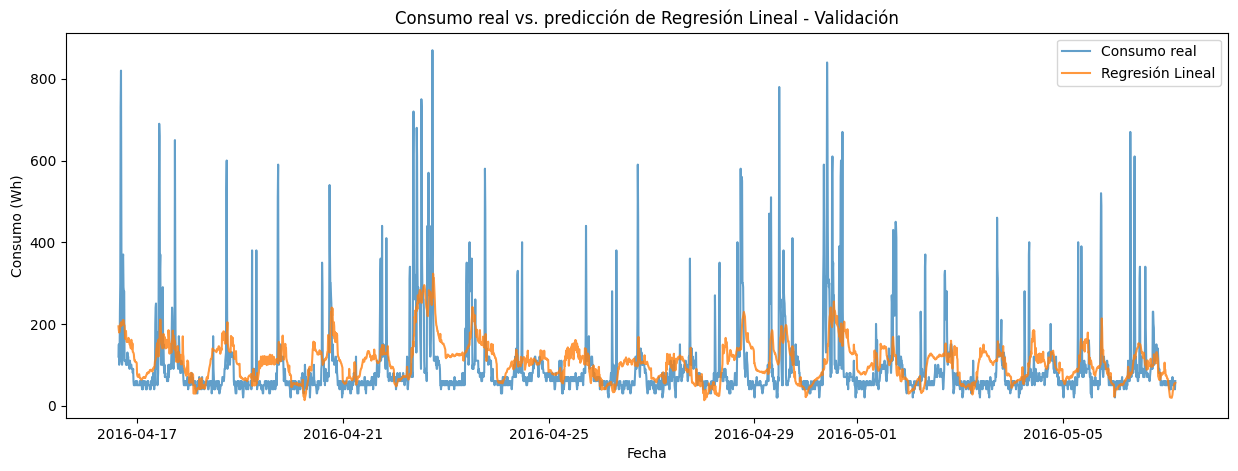

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    validation["date"],
    y_val,
    label="Consumo real",
    alpha=0.7
)

plt.plot(
    validation["date"],
    pred_linear,
    label="Regresión Lineal",
    alpha=0.8
)

plt.xlabel("Fecha")
plt.ylabel("Consumo (Wh)")
plt.title(
    "Consumo real vs. predicción de Regresión Lineal - Validación"
)
plt.legend()

plt.show()

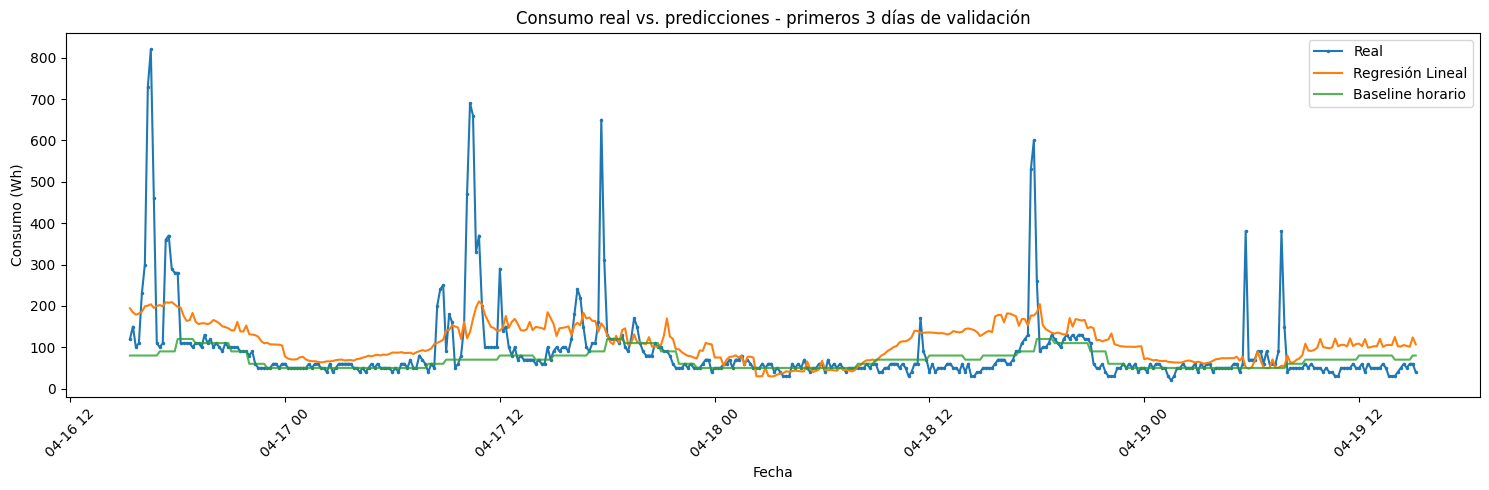

In [ ]:
ventana = errores.iloc[:432].copy()

plt.figure(figsize=(15, 5))

plt.plot(
    ventana["date"],
    ventana["Appliances"],
    label="Real",
    marker=".",
    markersize=3
)

plt.plot(
    ventana["date"],
    ventana["pred_linear"],
    label="Regresión Lineal"
)

plt.plot(
    ventana["date"],
    ventana["pred_hour"],
    label="Baseline horario",
    alpha=0.8
)

plt.xlabel("Fecha")
plt.ylabel("Consumo (Wh)")
plt.title(
    "Consumo real vs. predicciones - primeros 3 días de validación"
)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

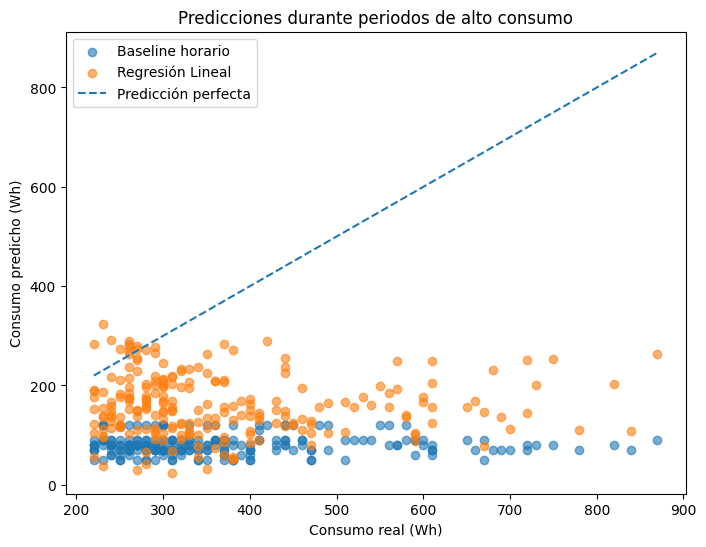

In [ ]:
alto_plot = errores[
    errores["high_consumption"]
].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    alto_plot["Appliances"],
    alto_plot["pred_hour"],
    alpha=0.6,
    label="Baseline horario"
)

plt.scatter(
    alto_plot["Appliances"],
    alto_plot["pred_linear"],
    alpha=0.6,
    label="Regresión Lineal"
)

limite_max = max(
    alto_plot["Appliances"].max(),
    alto_plot["pred_hour"].max(),
    alto_plot["pred_linear"].max()
)

plt.plot(
    [220, limite_max],
    [220, limite_max],
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Consumo real (Wh)")
plt.ylabel("Consumo predicho (Wh)")
plt.title("Predicciones durante periodos de alto consumo")

plt.legend()
plt.show()

In [ ]:
subestima_hour = (
    alto_plot["pred_hour"]
    < alto_plot["Appliances"]
).mean() * 100

subestima_linear = (
    alto_plot["pred_linear"]
    < alto_plot["Appliances"]
).mean() * 100

print(
    f"Baseline horario subestima "
    f"{subestima_hour:.2f}% de los episodios de alto consumo"
)

print(
    f"Regresión Lineal subestima "
    f"{subestima_linear:.2f}% de los episodios de alto consumo"
)

Baseline horario subestima 100.00% de los episodios de alto consumo
Regresión Lineal subestima 95.07% de los episodios de alto consumo


In [ ]:
resumen_segmentos = pd.DataFrame({
    "Segmento": [
        "Consumo normal (< 220 Wh)",
        "Consumo alto (>= 220 Wh)"
    ],
    "MAE Baseline horario": [
        normal["abs_error_hour"].mean(),
        alto["abs_error_hour"].mean()
    ],
    "MAE Regresión Lineal": [
        normal["abs_error_linear"].mean(),
        alto["abs_error_linear"].mean()
    ],
    "RMSE Baseline horario": [
        rmse_hour_normal,
        rmse_hour_high
    ],
    "RMSE Regresión Lineal": [
        rmse_linear_normal,
        rmse_linear_high
    ]
})

resumen_segmentos.round(2)

,Segmento,MAE Baseline horario,MAE Regresión Lineal,RMSE Baseline horario,RMSE Regresión Lineal
0,Consumo normal (< 220 Wh),16.17,39.69,23.89,50.57
1,Consumo alto (>= 220 Wh),290.40,212.64,322.06,259.33


## Conclusiones del modelado inicial

Los experimentos del Corte 1 muestran que no existe un único método que sea superior bajo todos los criterios de evaluación.

El baseline basado en la mediana por hora obtuvo el menor MAE global (36,83 Wh), superando tanto al baseline de mediana histórica como a los modelos lineales. Esto indica que la estructura horaria contiene información predictiva importante y permite representar adecuadamente una parte considerable de los consumos habituales.

Por otro lado, la Regresión Lineal obtuvo el menor RMSE (86,20 Wh) y el mayor R² (0,1266) entre los modelos evaluados. El análisis segmentado permitió explicar esta diferencia: durante periodos de consumo normal (< 220 Wh), el baseline horario obtuvo un MAE de 16,17 Wh frente a 39,69 Wh de la Regresión Lineal. Sin embargo, durante periodos de alto consumo (>= 220 Wh), la Regresión Lineal redujo el MAE de 290,40 Wh a 212,64 Wh.

A pesar de esta mejora relativa, la predicción de picos continúa siendo una limitación importante. El baseline horario subestimó el 100% de los episodios de alto consumo y la Regresión Lineal el 95,07%.

Ridge presentó resultados prácticamente idénticos a la Regresión Lineal, por lo que la regularización L2 con la configuración inicial utilizada no aportó una mejora relevante.

En consecuencia, el Corte 1 establece una línea base reproducible y evidencia que los modelos lineales capturan solamente una parte limitada de la dinámica del consumo. Los resultados justifican evaluar en etapas posteriores modelos capaces de representar relaciones no lineales e interacciones más complejas, manteniendo siempre una evaluación temporal y un análisis específico de los periodos de alto consumo.

In [ ]:
tabla_final = pd.DataFrame({
    "Modelo": [
        "Baseline mediana histórica",
        "Baseline mediana por hora",
        "Regresión Lineal",
        "Ridge"
    ],
    "MAE (Wh)": [
        mae_median,
        mae_hour,
        mae_linear,
        mae_ridge
    ],
    "RMSE (Wh)": [
        rmse_median,
        rmse_hour,
        rmse_linear,
        rmse_ridge
    ],
    "R²": [
        r2_median,
        r2_hour,
        r2_linear,
        r2_ridge
    ]
})

tabla_final.round({
    "MAE (Wh)": 2,
    "RMSE (Wh)": 2,
    "R²": 4
})

,Modelo,MAE (Wh),RMSE (Wh),R²
0,Baseline mediana histórica,42.60,98.11,-0.1313
1,Baseline mediana por hora,36.83,91.33,0.0195
2,Regresión Lineal,52.72,86.20,0.1266
3,Ridge,52.76,86.21,0.1265


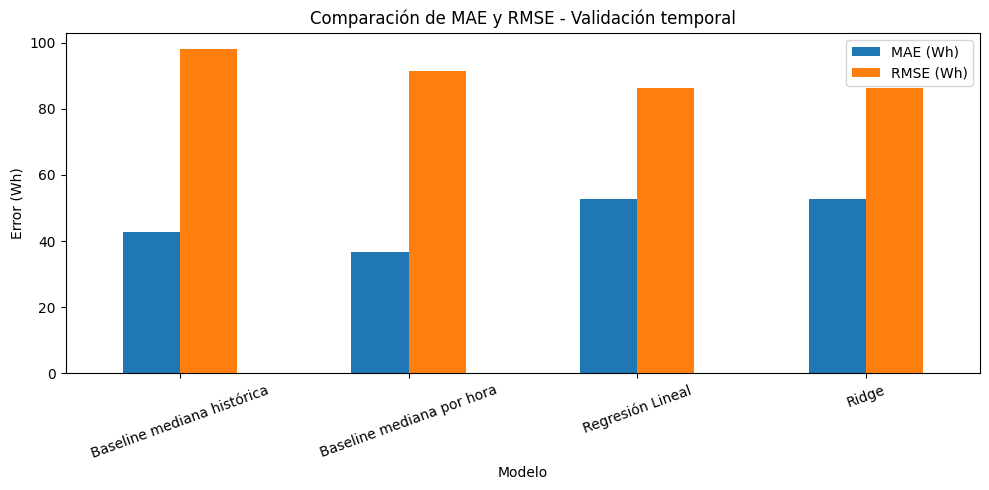

In [ ]:
comparacion_errores = tabla_final.set_index("Modelo")[
    ["MAE (Wh)", "RMSE (Wh)"]
]

comparacion_errores.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Error (Wh)")
plt.xlabel("Modelo")
plt.title("Comparación de MAE y RMSE - Validación temporal")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.show()

## Limitaciones identificadas en el Corte 1

1. **Dificultad para predecir picos:** los errores aumentan considerablemente durante episodios de consumo superior al percentil 90 del entrenamiento.

2. **Subestimación del consumo elevado:** el baseline horario subestimó el 100% de los episodios de alto consumo y la Regresión Lineal el 95,07%.

3. **Capacidad explicativa limitada:** aunque la Regresión Lineal mejora el RMSE y R² frente a los baselines, su R² de 0,1266 muestra que gran parte de la variabilidad continúa sin ser explicada.

4. **Relaciones potencialmente no lineales:** el EDA mostró patrones temporales que no necesariamente pueden representarse mediante relaciones lineales simples.

5. **Variabilidad temporal:** la frecuencia de episodios de alto consumo cambia entre entrenamiento, validación y prueba, por lo que una evaluación aleatoria podría ocultar diferencias temporales relevantes.

6. **Predicción no implica causalidad:** una variable útil para predecir el consumo no necesariamente constituye una causa del consumo ni demuestra que modificarla produciría ahorro energético.

7. **Alcance del dataset:** los resultados corresponden al edificio y periodo representados en los datos analizados, por lo que no puede asumirse automáticamente que el desempeño se generalice a otros edificios o condiciones.

## Estado del conjunto de prueba

El conjunto de prueba final, correspondiente al último 15% cronológico del dataset, se mantiene reservado.

Durante el Corte 1 no se utilizó el desempeño sobre Test para seleccionar variables, comparar configuraciones o escoger hiperparámetros. Las decisiones experimentales se realizaron utilizando Train y el bloque temporal de Validation.

Esta separación permitirá conservar una evaluación final independiente para etapas posteriores del proyecto.